In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Select Files


In [2]:
# data_dir = Path("data/LED_Trigger/260629")

files_ch = [
    ["data/LED_Trigger/260629/tri_seg_ch1.h5", "Channel 1"],
    ["data/LED_Trigger/260629/tri_seg_ch2.h5", "Channel 2"],
    ["data/LED_Trigger/260629/tri_seg_ch3.h5", "Channel 3"],
    ["data/LED_Trigger/260629/tri_seg_ch4.h5", "Channel 4"],
]


### if and where to save plots

In [3]:
save_plots = False
save_dir = 'plots_selection'
# file_nickname = file_name

# One channel at the time

In [4]:
max_sample_events = None

i = 0

sample = read_waveform_sample([files_ch[i][0]], max_events=max_sample_events, channel=files_ch[i][1])
time_ns = sample["time_ns"]
voltage_mV = sample["voltage_mV"]
adc_step_mV = sample["adc_step_mV"]
meta = sample["metadata"]

print(meta[0]['channel'])


voltage_mV.shape


Channel 1


(31682, 6401)

Text(0.5, 1.0, 'Mean Waveform')

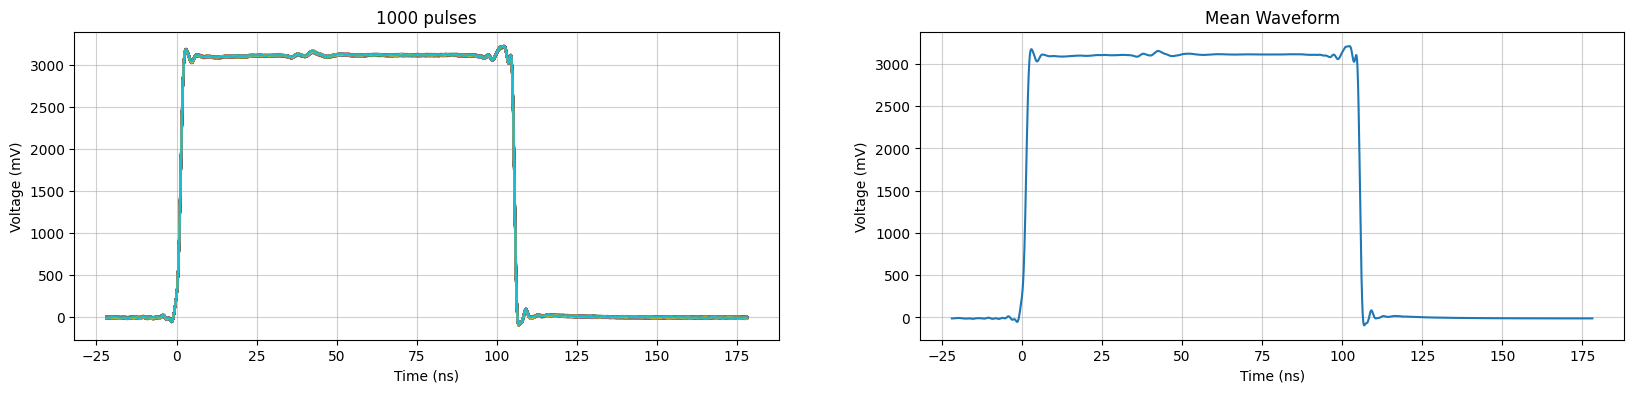

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(20,4))
axes = axes.ravel()
add_plot_waveforms(
    axes[0],
    time_ns,
    voltage_mV[:1000],
)
axes[0].set_title('1000 pulses')
add_mean_waveform( axes[1], time_ns, voltage_mV);
axes[1].set_xlabel('Time (ns)')
axes[1].set_ylabel('Voltage (mV)')
axes[1].set_title('Mean Waveform')

Text(0.5, 0, 'cfd50_rise_ns')

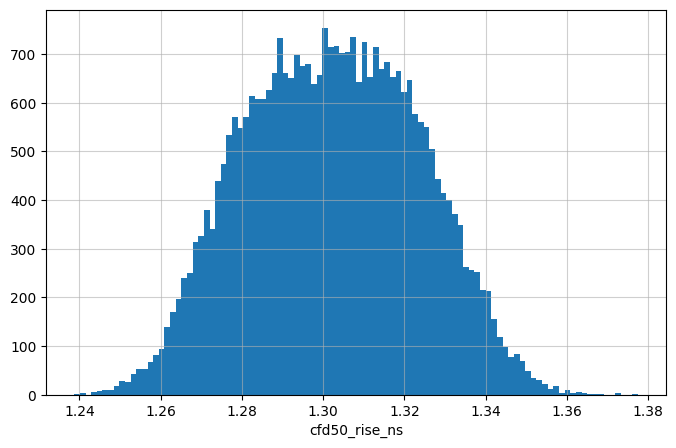

In [6]:
cfd50_rise_ns = np.array([ _fractional_crossing_time( time_ns, waveform, 0.5, rising=True, ) for waveform in voltage_mV ] )
plt.hist(cfd50_rise_ns, bins=100);
plt.xlabel('cfd50_rise_ns')

# Look at different channels

In [7]:
max_sample_events = None

channels = {

}

for i in [0, 1, 2, 3]:
    sample = read_waveform_sample([files_ch[i][0]], max_events=max_sample_events, channel=files_ch[i][1])
    time_ns = sample["time_ns"]
    voltage_mV = sample["voltage_mV"]
    adc_step_mV = sample["adc_step_mV"]
    meta = sample["metadata"]
    channels[f'ch{i+1}'] = {
        'time_ns': time_ns,
        'voltage_mV': voltage_mV,
        'meta': meta,
    }


In [8]:
channels.keys()

dict_keys(['ch1', 'ch2', 'ch3', 'ch4'])

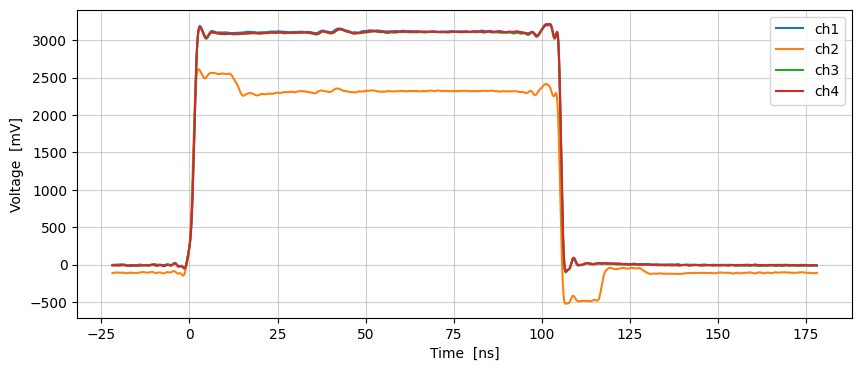

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10,4))
for ch in channels:
    for wf in channels[ch]['voltage_mV'][:1]:
        ax.plot(channels[ch]['time_ns'], wf, label=ch)
ax.set_xlabel('Time  [ns]')
ax.set_ylabel('Voltage  [mV]')
ax.legend();

In [10]:
cfd50_rise_ns = []
for ch in channels:
    cfd50_rise_ns.append( np.array([ _fractional_crossing_time( channels[ch]['time_ns'], waveform, 0.5, rising=True, ) for waveform in channels[ch]['voltage_mV'] ] ) )

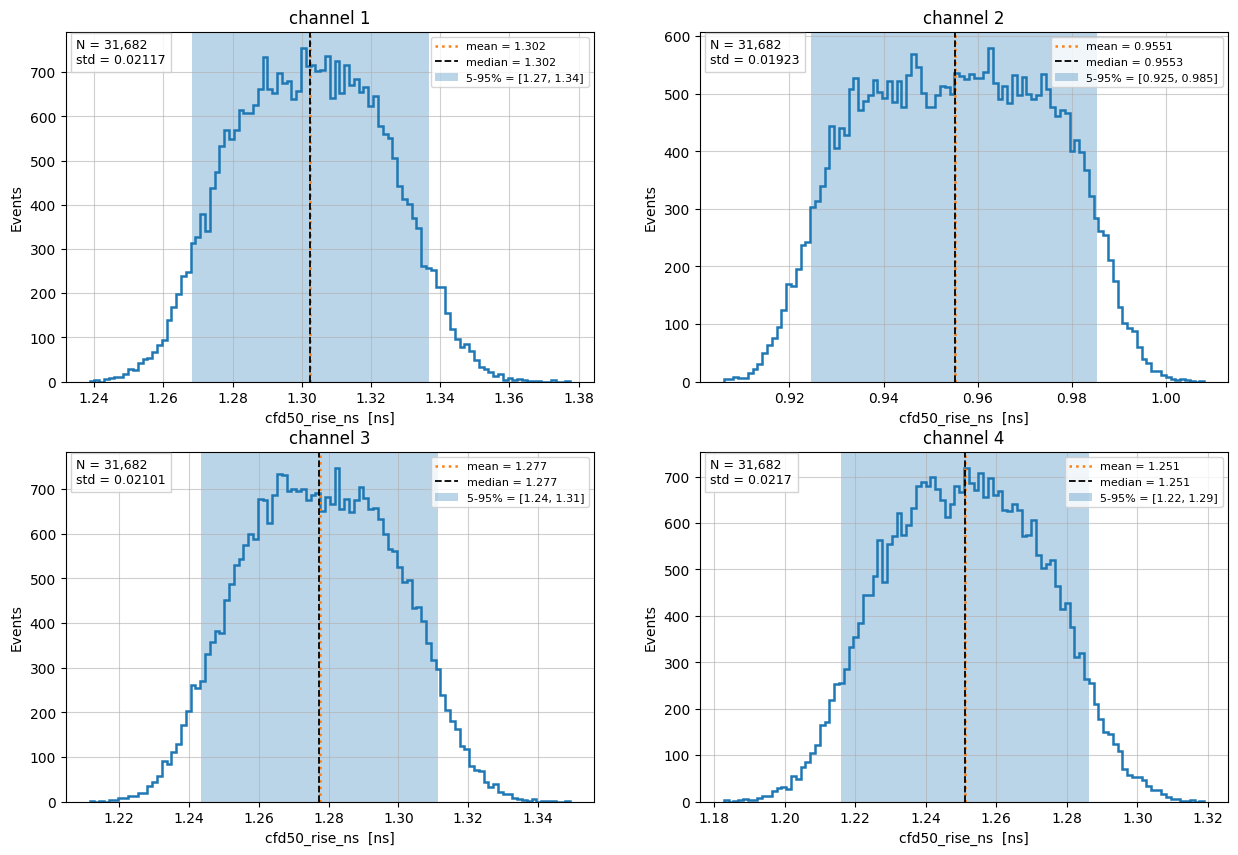

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))
axes = axes.ravel()
for i in range(0, 4):
    add_hist_stats(axes[i], cfd50_rise_ns[i], 100, None, 'cfd50_rise_ns  [ns]', f'channel {i+1}', unit="", show_stat=True, text_position=(0.02, 0.98), legend_loc="best")


In [ ]:
channels['ch1']['meta'][0].keys()

# useful:
# 'time_tags'
# 'x_origins'

dict_keys(['filename', 'file_type', 'frame', 'channel', 'channel_attrs', 'segment_numbers', 'layout', 'time_tags', 'x_origins', 'segment_attrs'])

In [ ]:
# channels['ch1']['meta'][0]['channel_attrs']
# channels['ch1']['meta'][0]['segment_attrs']


In [ ]:
channels['ch1']['meta'][0]['time_tags']

In [43]:

c1 = channels['ch1']['meta'][0]['time_tags']
c2 = channels['ch2']['meta'][0]['time_tags']
c3 = channels['ch3']['meta'][0]['time_tags']
c4 = channels['ch4']['meta'][0]['time_tags']

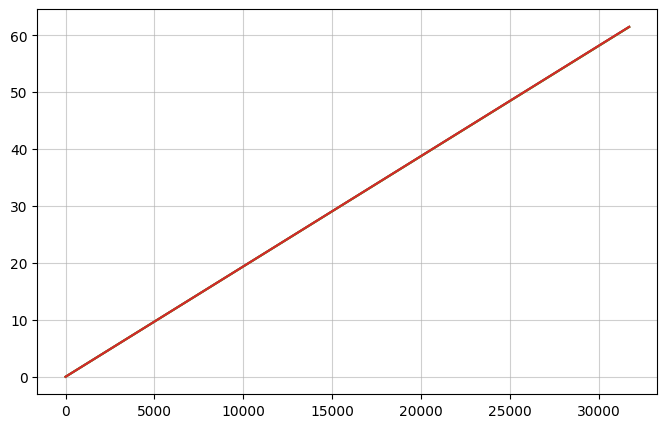

In [44]:
plt.plot(np.arange(0, len(c1)), c1, label='ch1')
plt.plot(np.arange(0, len(c2)), c2, label='ch2')
plt.plot(np.arange(0, len(c3)), c3, label='ch3')
plt.plot(np.arange(0, len(c4)), c4, label='ch4')